In [1]:
# !pip install xgboost lightgbm catboost

# Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression , Lasso ,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # Needed for HistGB
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,
                              AdaBoostRegressor ,GradientBoostingRegressor,HistGradientBoostingRegressor
                              , VotingRegressor,StackingRegressor)
#import xgboost as xgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
#import lightgbm as lgb
from lightgbm import LGBMRegressor

c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:18: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [3]:
df= pd.read_csv('Rent.csv')

In [4]:
df.head()

,BHK,Rent,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
0,2,10000.0,1100.000000,454,220,4,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,20000.0,967.936049,14,1525,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,17000.0,1000.000000,14,1758,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2,10000.0,967.936049,10,525,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2,7500.0,850.000000,10,1888,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [5]:
df.shape

(4727, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4727 entries, 0 to 4726
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHK            4727 non-null   int64  
 1   Rent           4727 non-null   float64
 2   Size           4727 non-null   float64
 3   Floor          4727 non-null   int64  
 4   Area Locality  4727 non-null   int64  
 5   City           4727 non-null   int64  
 6   Bathroom       4727 non-null   float64
 7   N_11           4727 non-null   float64
 8   N_12           4727 non-null   float64
 9   N_13           4727 non-null   float64
 10  N_14           4727 non-null   float64
 11  N_15           4727 non-null   float64
 12  N_16           4727 non-null   float64
 13  N_17           4727 non-null   float64
 14  N_18           4727 non-null   float64
 15  N_19           4727 non-null   float64
 16  N_20           4727 non-null   float64
 17  N_21           4727 non-null   float64
 18  N_22    

In [7]:
X=df.drop('Rent',axis =1)
y= df[['Rent']]

In [8]:
X.head()

,BHK,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
0,2,1100.000000,454,220,4,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,967.936049,14,1525,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,1000.000000,14,1758,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2,967.936049,10,525,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2,850.000000,10,1888,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [9]:
y.head()

,Rent
0,10000.0
1,20000.0
2,17000.0
3,10000.0
4,7500.0


In [ ]:
# Split into Input and Output Elements
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   test_size= 0.20, random_state=100)

In [ ]:
print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (3781, 18)  y_train =  (3781, 1)
X_test  =  (946, 18)  y_test  =  (946, 1)


In [ ]:
# MinMaxScaler
my_scaler = MinMaxScaler(feature_range=(0,1))
X_train = my_scaler.fit_transform(X_train)
X_test = my_scaler.transform(X_test)

In [13]:
models ={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNN":KNeighborsRegressor(n_neighbors=5,metric='minkowski',p=1), #  minkowski , euclidean , manhattan
    "SVM":SVR(kernel='linear', C=100, gamma=1), # kernel='rbf' / kernel='poly', degree=4 / kernel='sigmoid
    "Decision Tree":DecisionTreeRegressor(criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "Random Forest":RandomForestRegressor(n_estimators=50,criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Bagging": BaggingRegressor(estimator=DecisionTreeRegressor(criterion='squared_error',max_depth=10),n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=15, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0, iterations=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

In [14]:
# Metrics function
def regression_metrics(model, X, y_actual):
    y_pred = model.predict(X)
    MAE = mean_absolute_error(y_actual, y_pred)
    MSE = mean_squared_error(y_actual, y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_actual, y_pred)
    return MAE, MSE, RMSE, R2

  0%|          | 0/15 [00:00<?, ?it/s]

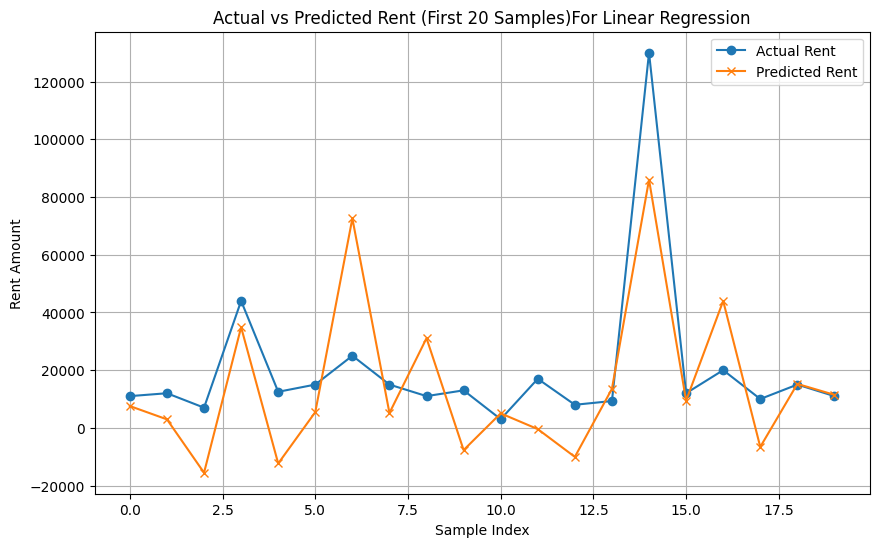

  7%|▋         | 1/15 [00:00<00:02,  5.50it/s]

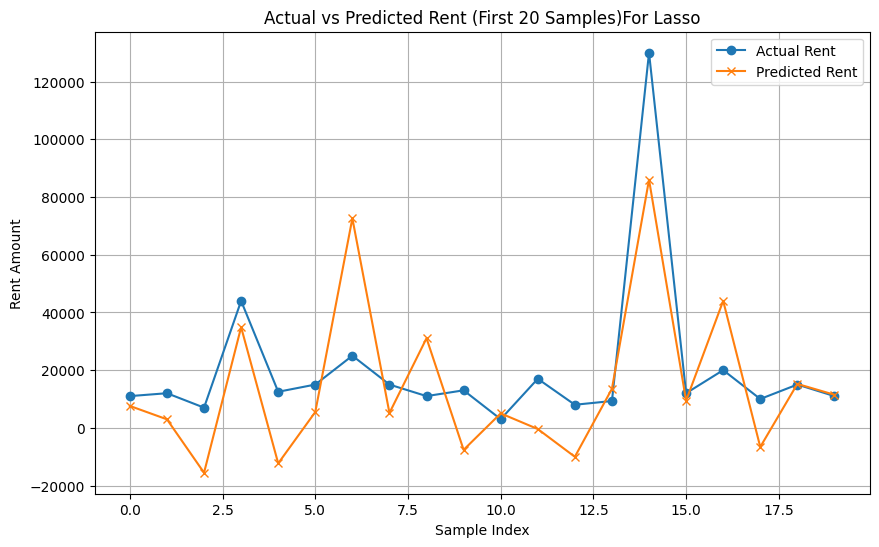

 13%|█▎        | 2/15 [00:00<00:02,  5.19it/s]

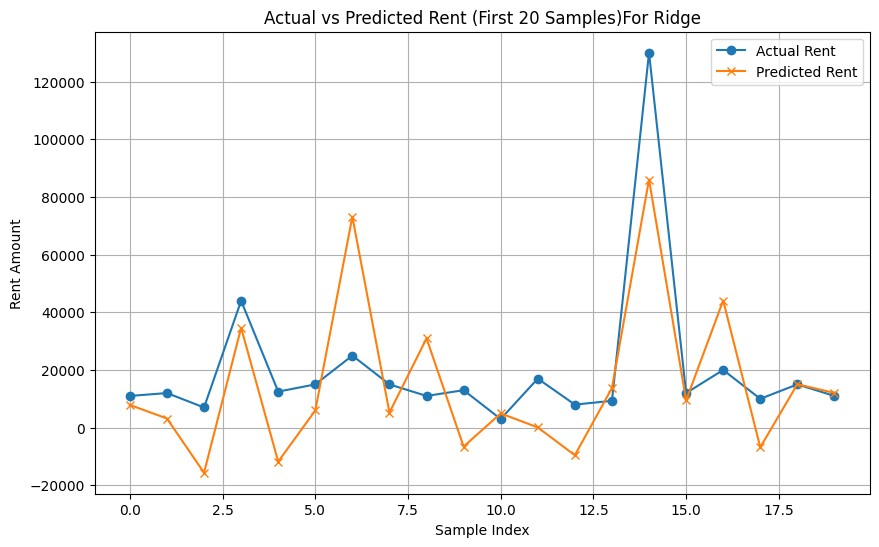

 20%|██        | 3/15 [00:00<00:02,  5.58it/s]

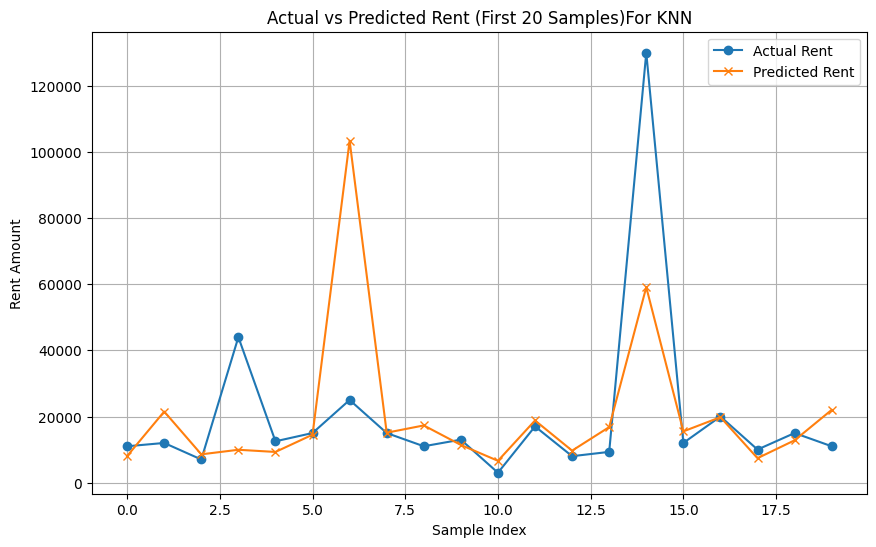

 27%|██▋       | 4/15 [00:02<00:08,  1.30it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


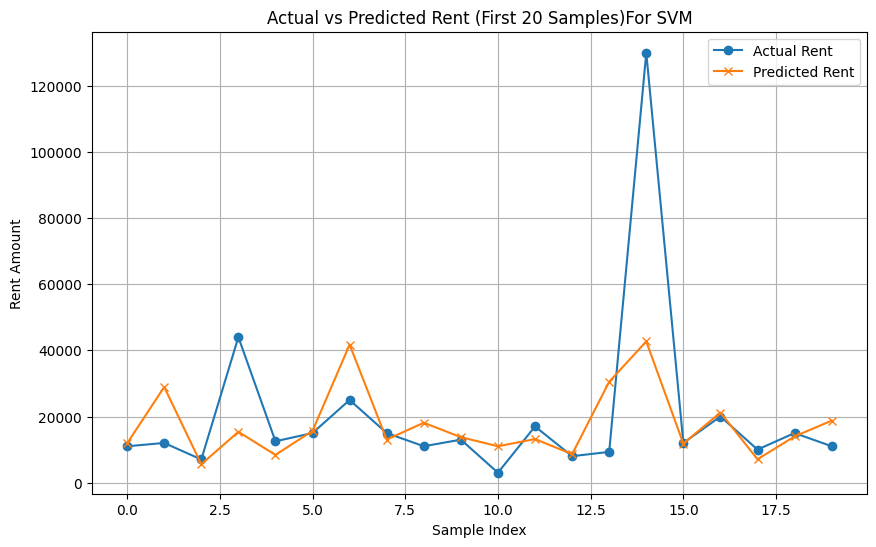

 33%|███▎      | 5/15 [00:03<00:07,  1.26it/s]

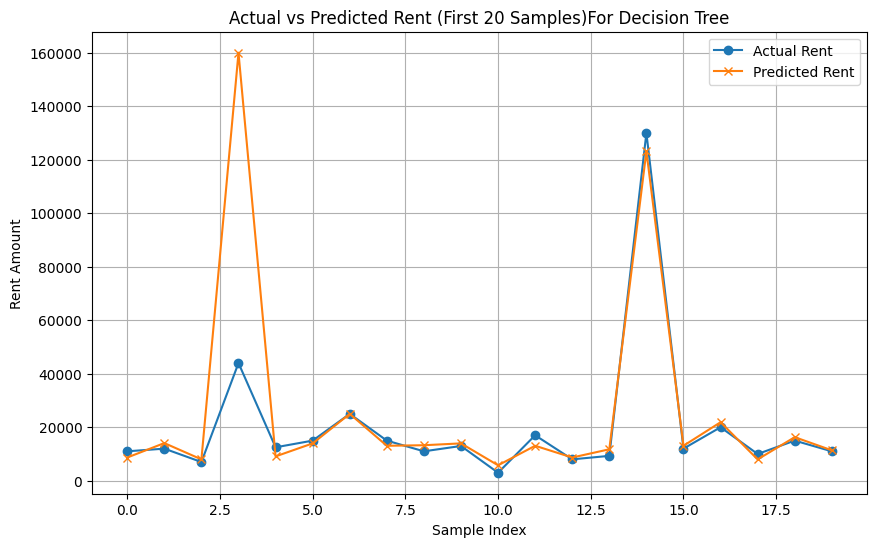

 40%|████      | 6/15 [00:03<00:05,  1.73it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


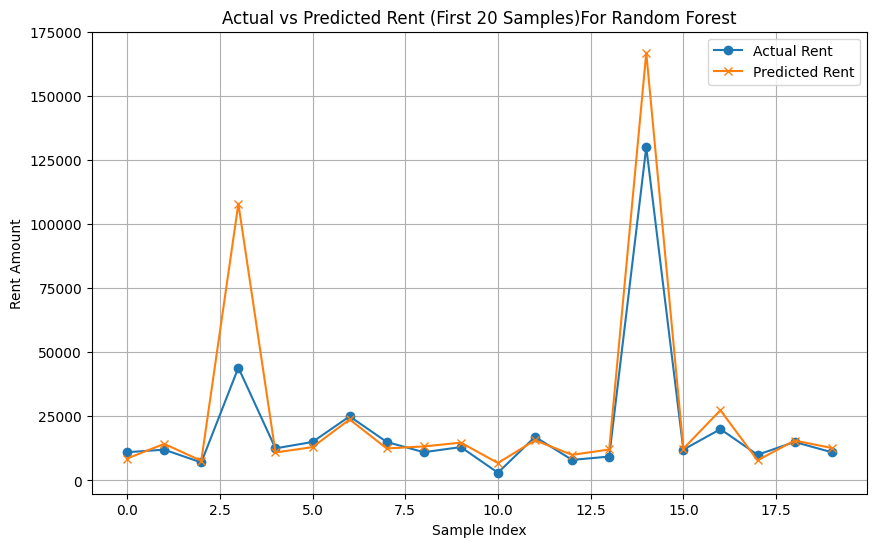

 47%|████▋     | 7/15 [00:03<00:04,  1.72it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


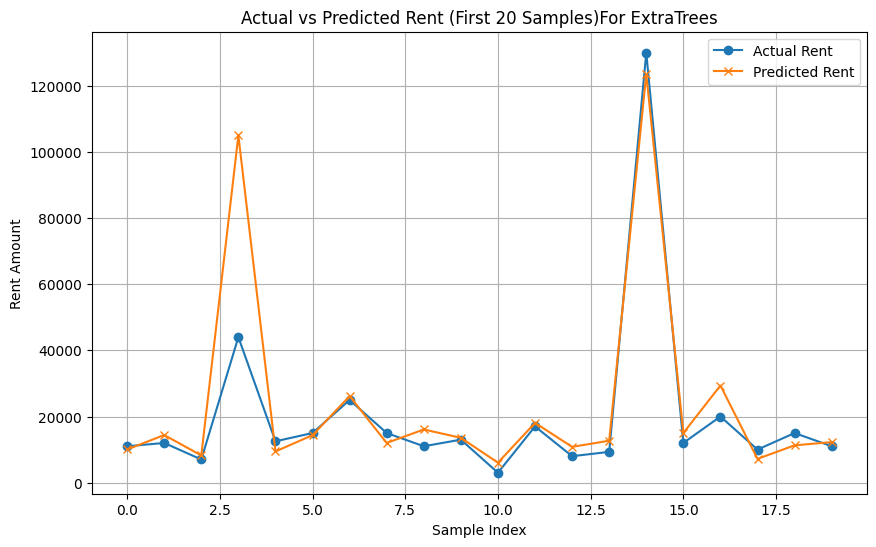

 53%|█████▎    | 8/15 [00:05<00:05,  1.26it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\ensemble\_bagging.py:583: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


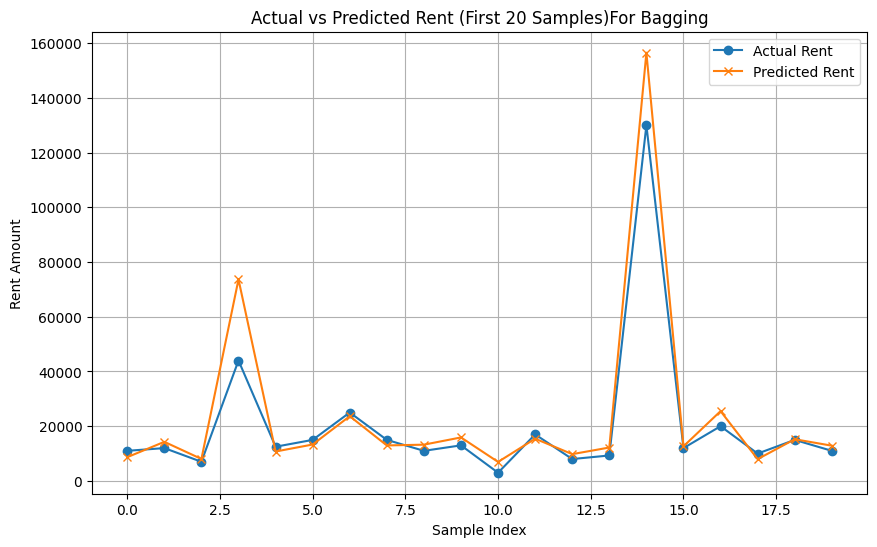

 60%|██████    | 9/15 [00:05<00:04,  1.34it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


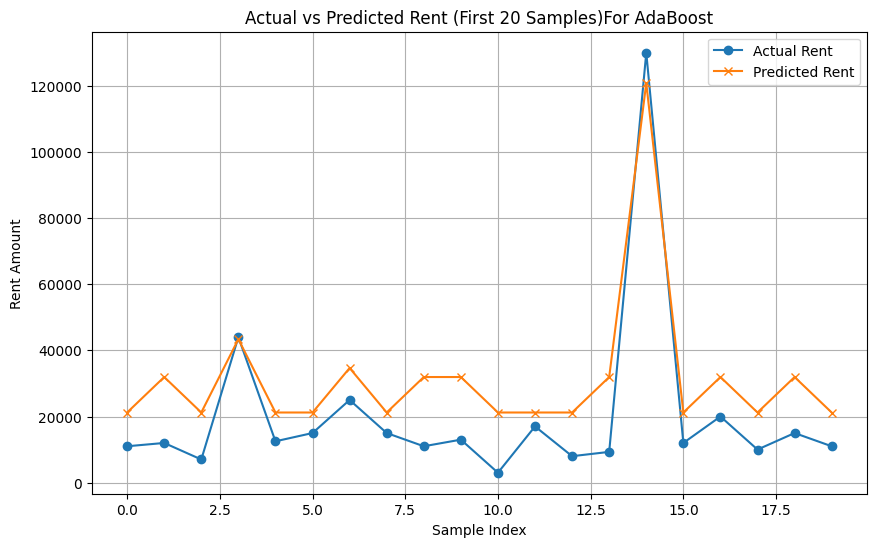

 67%|██████▋   | 10/15 [00:05<00:02,  1.70it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


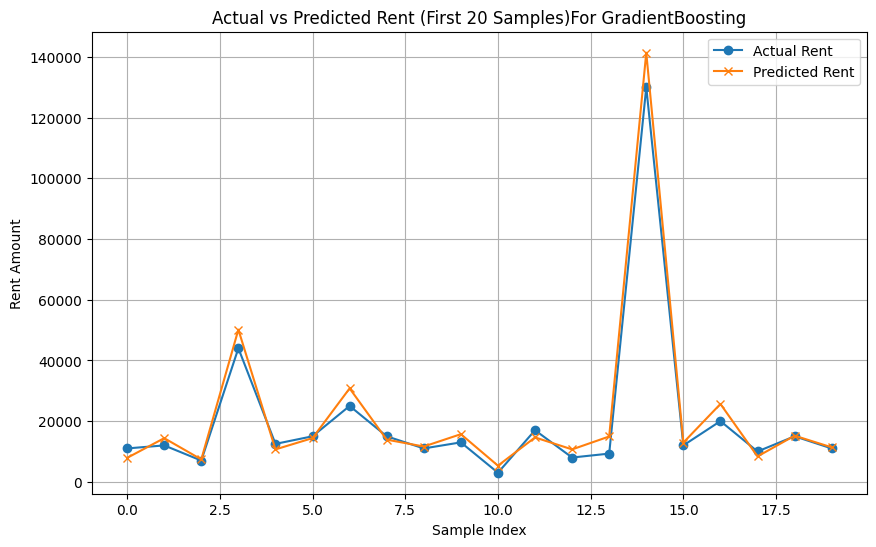

 73%|███████▎  | 11/15 [00:06<00:02,  1.73it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


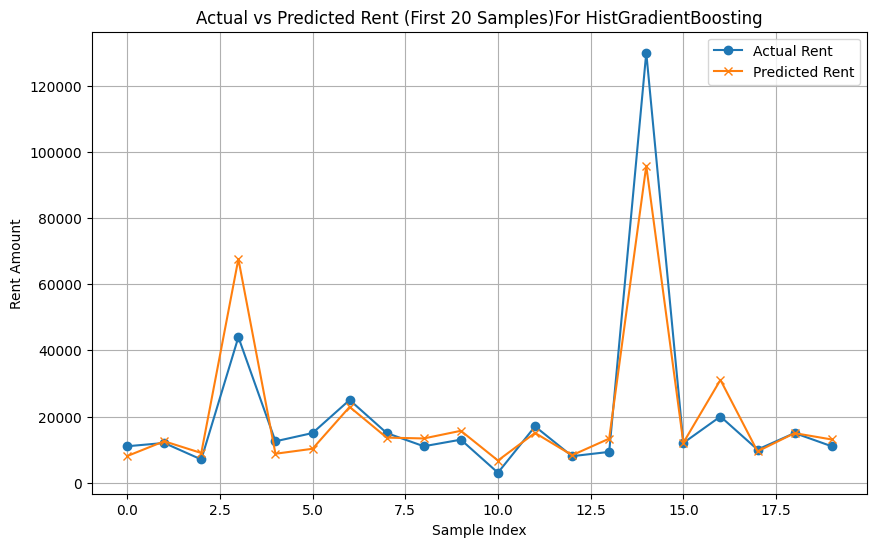

 80%|████████  | 12/15 [00:06<00:01,  1.88it/s]

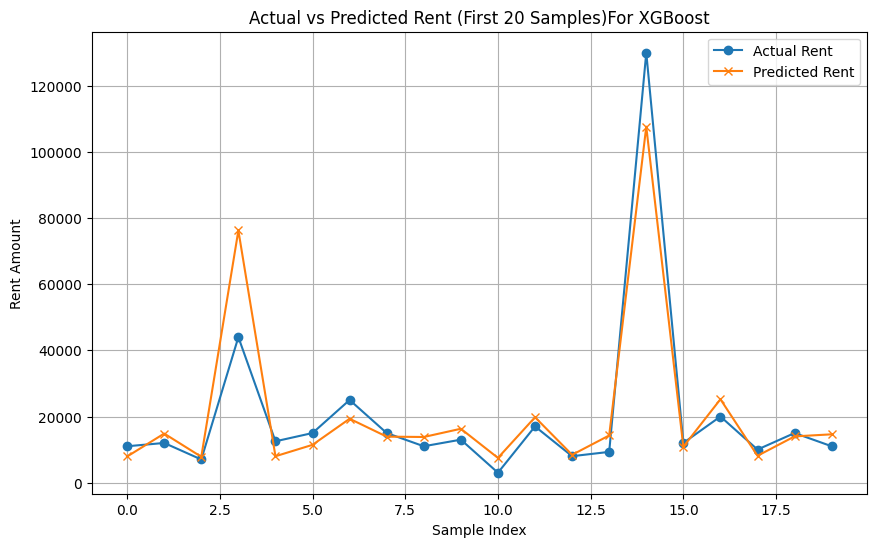

 87%|████████▋ | 13/15 [00:07<00:01,  1.92it/s]

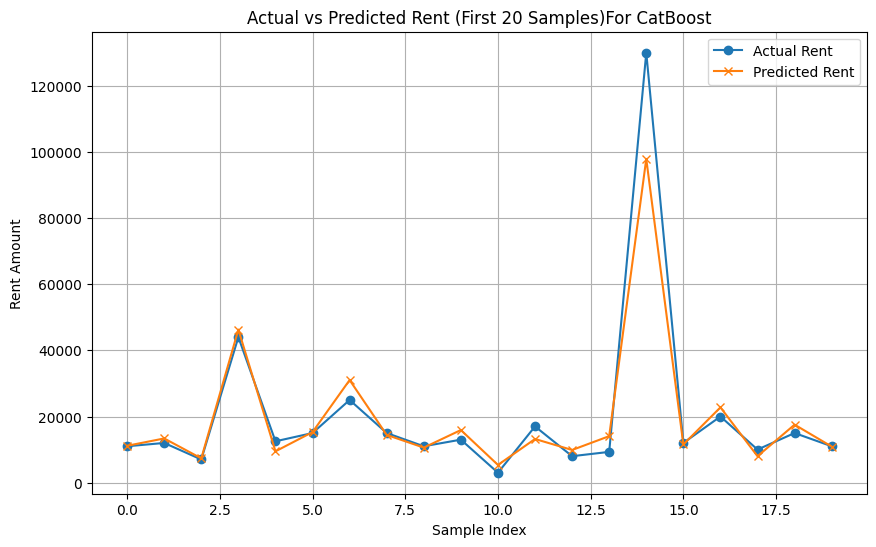

 93%|█████████▎| 14/15 [00:08<00:00,  1.79it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 762
[LightGBM] [Info] Number of data points in the train set: 3781, number of used features: 16
[LightGBM] [Info] Start training from score 33585.680243


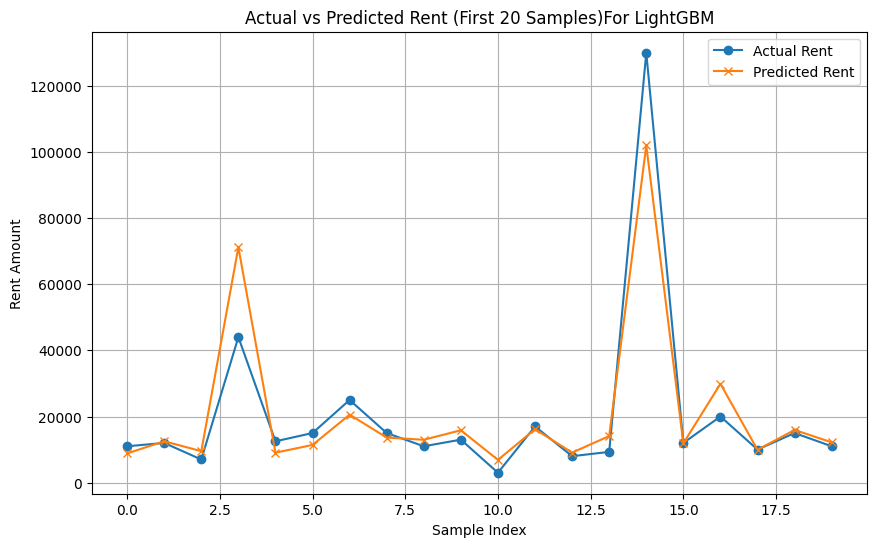

100%|██████████| 15/15 [00:08<00:00,  1.80it/s]


In [ ]:
errors={}
for model_name , model in tqdm(models.items()):
    model.fit(X_train,y_train)
    MAE_Train, MSE_Train, RMSE_Train, R_Train = regression_metrics(model, X_train, y_train)
    MAE_Test, MSE_Test, RMSE_Test, R_Test = regression_metrics(model, X_test, y_test)
    
    errors[model_name] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R_Train,
        "R2 Test":R_Test
    }

    #Plotting Actual vs Predicted for first 20 test samples
    y_test_plot = y_test.values[:20]
    y_pred_plot = model.predict(X_test[:20])

    plt.figure(figsize=(10,6))
    plt.plot(range(20), y_test_plot, label='Actual Rent', marker='o')
    plt.plot(range(20), y_pred_plot, label='Predicted Rent', marker='x')
    plt.xlabel('Sample Index')
    plt.ylabel('Rent Amount')
    plt.title('Actual vs Predicted Rent (First 20 Samples)For '+ model_name)
    plt.legend()
    plt.grid()
    plt.show()

# Votting Regression

In [ ]:
# Create individual regressors
clf1 = LinearRegression()
clf2 = RandomForestRegressor(n_estimators=50, random_state=1)
clf3 = DecisionTreeRegressor(random_state=1)

# Voting Regressors (only averaging is supported)
model1 = VotingRegressor(estimators=[
    ('lr', clf1), ('rf', clf2), ('dt', clf3)
])

model2 = VotingRegressor(estimators=[
    ('lr', clf1), ('rf', clf2), ('dt', clf3)
])

# Weighted averaging
model3 = VotingRegressor(estimators=[
    ('lr', clf1), ('rf', clf2), ('dt', clf3)
], weights=[2, 1, 2])

# Fit models
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)


# Model 1
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(model1, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(model1, X_test, y_test)

errors["Voting"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }

# Model 2
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(model2, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(model2, X_test, y_test)
errors["Simple Voting"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }

# Model 3
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(model3, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(model3, X_test, y_test)
errors["Weighted Voting"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }


c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Stacking Regression

In [ ]:
# -----------------------------
# Base models for stacking
# -----------------------------
regressors = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, random_state=42)),
    ('cat', CatBoostRegressor(iterations=50, learning_rate=0.1, verbose=0)),
    ('lgb', LGBMRegressor(n_estimators=50, learning_rate=0.1, random_state=42))
]

# -----------------------------
# Meta-model
# -----------------------------
meta_regressor = XGBRegressor()

# -----------------------------
# Stacking Models
# -----------------------------
stacking_regressor = StackingRegressor(
    estimators=regressors,
    final_estimator=meta_regressor,
    cv=5,
    passthrough=True,
    n_jobs=-1
)


stacking_regressor.fit(X_train, y_train)
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(stacking_regressor, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(stacking_regressor, X_test, y_test)
errors["Stacking"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }

c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\ensemble\_stacking.py:1041: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
errors_df = pd.DataFrame(errors).T.sort_values(by="R2 Test",ascending=False)

In [19]:
errors_df

,MAE Train,MAE Test,MSE Train,MSE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
Voting,7950.599978,11198.095989,3.838573e+08,6.405202e+08,19592.275917,25308.500497,0.912719,0.770139
Simple Voting,7950.599978,11198.095989,3.838573e+08,6.405202e+08,19592.275917,25308.500497,0.912719,0.770139
LightGBM,7950.599978,11198.095989,3.838573e+08,6.405202e+08,19592.275917,25308.500497,0.885984,0.766850
Weighted Voting,7950.599978,11198.095989,3.838573e+08,6.405202e+08,19592.275917,25308.500497,0.894311,0.763788
HistGradientBoosting,8088.210208,11379.558551,3.937271e+08,6.588238e+08,19842.556966,25667.562592,0.883052,0.760188
Bagging,6626.662274,10834.135747,1.930736e+08,7.105423e+08,13895.094323,26655.999973,0.942652,0.741362
GradientBoosting,9486.718100,11648.460481,4.151556e+08,7.433013e+08,20375.366783,27263.551737,0.876687,0.729438
Random Forest,6634.545174,11478.406201,1.846370e+08,7.773164e+08,13588.119949,27880.394603,0.945158,0.717056
CatBoost,9074.738854,11955.077475,3.915810e+08,7.923677e+08,19788.404766,28149.026356,0.883689,0.711578
Stacking,7950.599978,11198.095989,3.838573e+08,6.405202e+08,19592.275917,25308.500497,0.890932,0.708253


<Axes: >

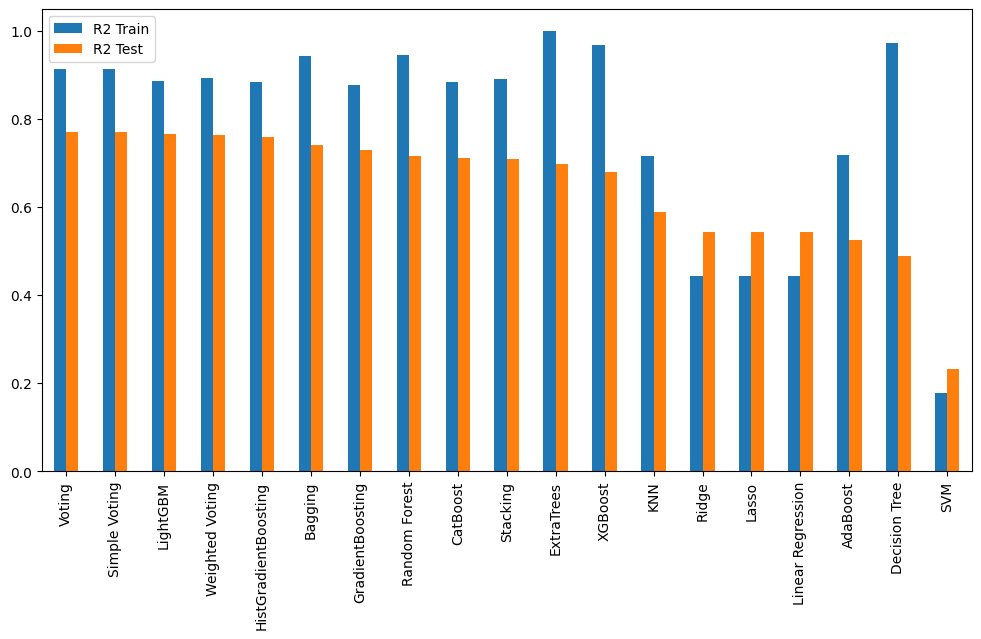

In [21]:
errors_df[["R2 Train", "R2 Test"]].plot.bar(figsize=(12,6))

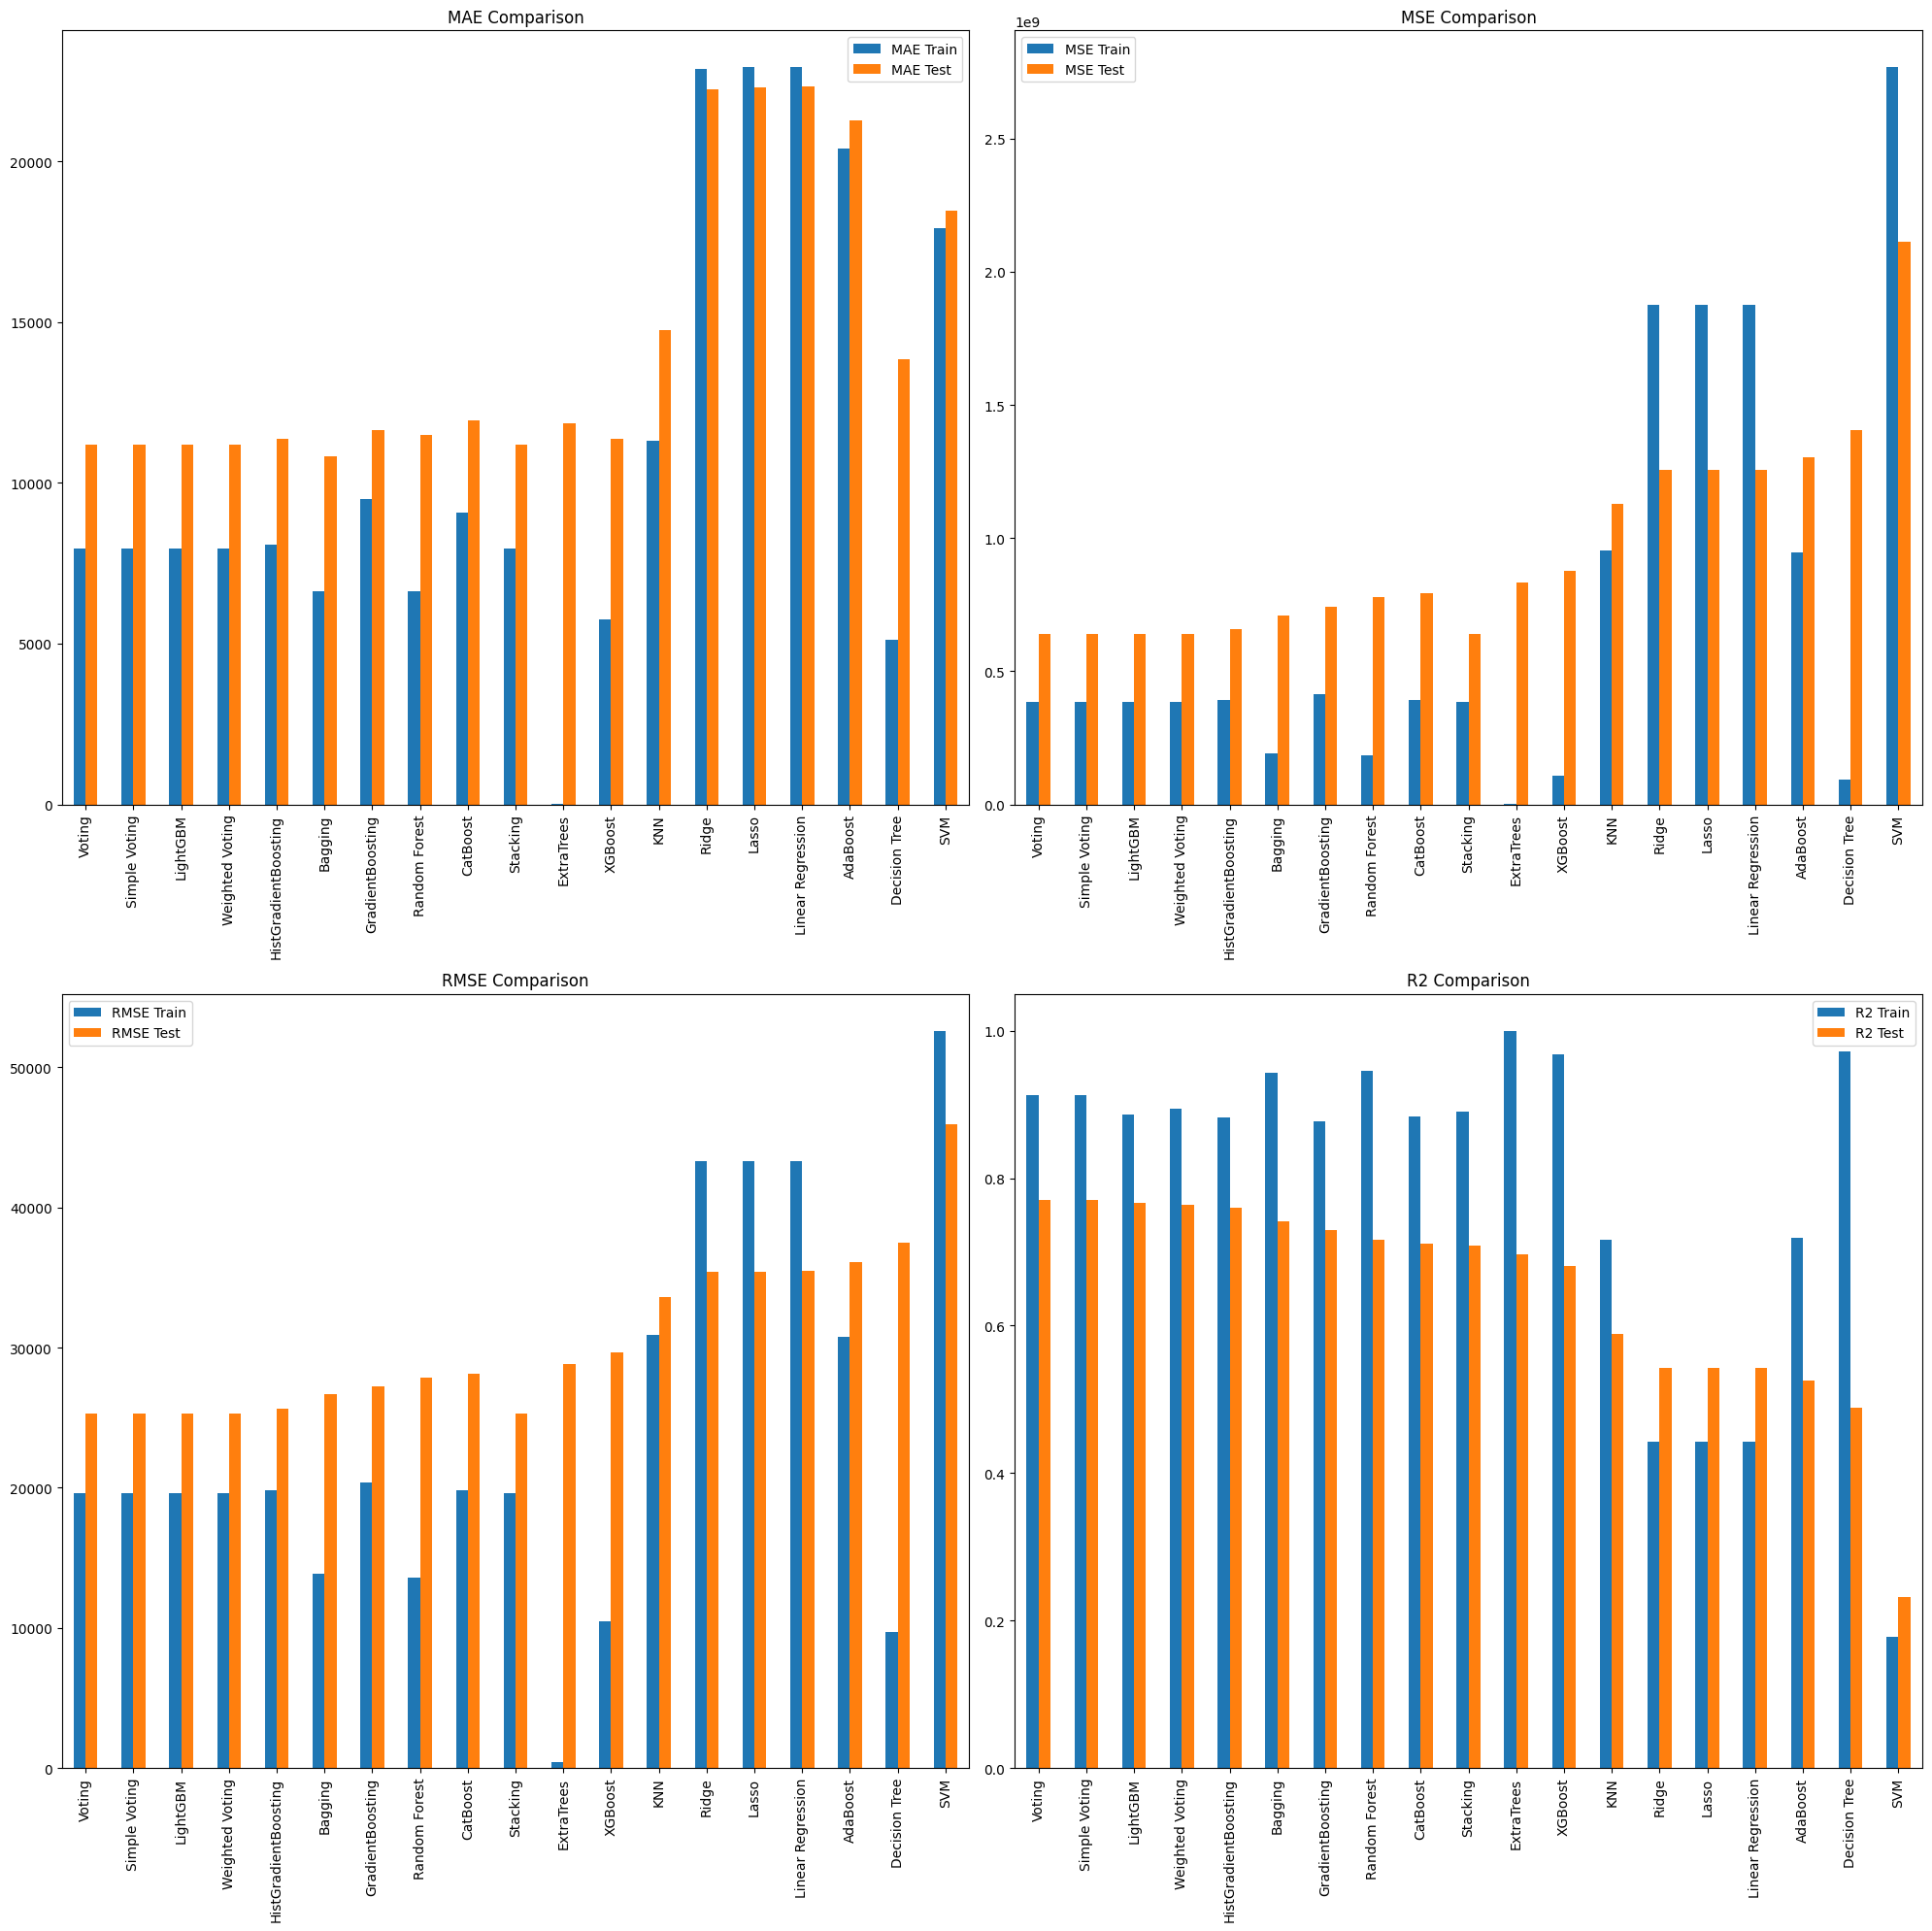

In [23]:
cols = [
    ['MAE Train', 'MAE Test'],
    ['MSE Train', 'MSE Test'],
    ['RMSE Train', 'RMSE Test'],
    ['R2 Train', 'R2 Test']
]

plt.figure(figsize=(20,20))

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i+1)   
    errors_df[col].plot.bar(ax=ax)   
    ax.set_title(col[0].split(" ")[0] + ' Comparison')

plt.tight_layout()
plt.show()